# Results analysis & figures — VMD–Optuna–TCN building electricity forecasting

This notebook reads the CSVs written by `run_all_experiments.py` and produces every
**table** and **figure** needed for the manuscript, all in **Times New Roman**:

1. Main results table (test set) + LaTeX
2. Aggregated mean ± std across seeds + LaTeX
3. Seven-day forecast figure (`7day_forecast.png`)
4. Predicted-vs-actual scatter figure (`scatter.png`)
5. Absolute-error box plot (`absolute_error.png`)
6. Ablation table + LaTeX
7. Computational-cost table + LaTeX
8. Statistical-test tables (Wilcoxon / Friedman) + LaTeX
9. Generalization table (holdout + unseen building) + LaTeX
10. *(optional)* building distribution & VMD IMF overlay

Run the cells top to bottom. Every cell is defensive: if an input file is missing it
prints a note and skips, so you can run it even after a partial experiment.

In [1]:
# === Setup: imports, paths, Times New Roman ===========================
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---- where the experiment wrote its outputs -------------------------------
RESULTS_DIR = "results_all_experiments"          # change if yours differs
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
PRED_DIR    = os.path.join(RESULTS_DIR, "predictions")
STATS_DIR   = os.path.join(RESULTS_DIR, "statistics")
FIG_DIR     = "figures"; os.makedirs(FIG_DIR, exist_ok=True)

# ---- Times New Roman (with graceful fallback) -----------------------------
def set_times_new_roman():
    # If you have the .ttf, point to it here to guarantee the exact face:
    #   font_manager.fontManager.addfont("/path/to/Times New Roman.ttf")
    preferred = ["Times New Roman", "Times", "Liberation Serif", "Nimbus Roman", "DejaVu Serif"]
    have = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in preferred if n in have), "serif")
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [chosen],
        "mathtext.fontset": "stix",
        "axes.unicode_minus": False,
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })
    print("Serif font in use:", chosen)
    if chosen != "Times New Roman":
        print("NOTE: true 'Times New Roman' not installed; using a metric-compatible "
              "serif. On the machine that renders the final figures, install the font "
              "or addfont() the .ttf for an exact match.")
set_times_new_roman()

def load_csv(path):
    if not os.path.exists(path):
        print("  (missing)", path); return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print("  (failed to read)", path, "->", e); return None

# Display order / pretty names
MODEL_ORDER   = ["GRU", "LSTM", "Transformer", "VMD_Optuna_TCN"]
PRETTY = {"GRU":"GRU", "LSTM":"LSTM", "Transformer":"Transformer",
          "TCN":"TCN (raw)", "VMD_TCN":"VMD+TCN", "VMD_Optuna_TCN":"Proposed"}
BUILDING_ORDER = ["Wolf", "Bull", "Robin", "Fox", "Rat", "Eagle"]
print("Setup complete.")

Serif font in use: Times New Roman
Setup complete.


## 1. Load results

In [2]:
metrics = load_csv(os.path.join(METRICS_DIR, "all_metrics.csv"))
preds   = load_csv(os.path.join(PRED_DIR, "all_predictions_long.csv"))
complexity = load_csv(os.path.join(METRICS_DIR, "model_complexity.csv"))

if metrics is not None:
    # If multiple seeds, average per Model/Dataset/Building for point tables.
    keys = ["Model", "Dataset", "Building"]
    num_cols = [c for c in ["MAE","MSE","RMSE","MAPE","SMAPE","R2",
                            "Training_Time_sec","Testing_Time_sec"] if c in metrics.columns]
    metrics_mean = metrics.groupby(keys, as_index=False)[num_cols].mean()
    print("Models found :", sorted(metrics["Model"].unique()))
    print("Datasets     :", sorted(metrics["Dataset"].unique()))
    display(metrics_mean.head())
else:
    metrics_mean = None
    print("Run run_all_experiments.py first to generate", METRICS_DIR)

Models found : ['GRU', 'LSTM', 'TCN', 'Transformer', 'VMD_Optuna_TCN', 'VMD_TCN']
Datasets     : ['cross', 'holdout', 'test']


,Model,Dataset,Building,MAE,MSE,RMSE,MAPE,SMAPE,R2,Training_Time_sec,Testing_Time_sec
0,GRU,cross,Hog,1.698305,5.269230,2.295480,2.535629,2.528164,0.845461,62.7043,0.0401
1,GRU,holdout,Bull,1.542055,4.176397,2.043623,7.859731,7.455423,0.654788,62.7043,0.0076
2,GRU,holdout,Eagle,1.507909,6.462482,2.542141,4.474232,4.380700,0.602546,62.7043,0.0077
3,GRU,holdout,Fox,3.249945,24.816320,4.981598,4.889659,4.581070,0.792150,62.7043,0.0072
4,GRU,holdout,Rat,3.378785,21.026485,4.585465,13.285629,12.134641,0.801717,62.7043,0.0073


## 2. Main results table (test set) + LaTeX

Rows are buildings × metrics; columns are the baselines and the proposed model.
The best value per row is **bolded**. A `booktabs` LaTeX version is written to
`figures/table_main_results.tex` so you can drop it straight into the manuscript.

In [3]:
def fmt(v, nd=2): return "" if pd.isna(v) else f"{v:.{nd}f}"

def build_main_table(df, dataset="test",
                     metrics_list=("MAE","RMSE","MAPE","SMAPE","R2")):
    d = df[df["Dataset"] == dataset]
    models = [m for m in MODEL_ORDER if m in d["Model"].unique()]
    rows = []
    for b in [x for x in BUILDING_ORDER if x in d["Building"].unique()]:
        for met in metrics_list:
            vals = {}
            for m in models:
                sub = d[(d["Building"]==b) & (d["Model"]==m)]
                vals[m] = float(sub[met].iloc[0]) if len(sub) and met in sub else np.nan
            rows.append({"Building": b, "Metric": met, **vals})
    return pd.DataFrame(rows), models

if metrics_mean is not None:
    main_tbl, models = build_main_table(metrics_mean, "test")
    # numeric preview
    display(main_tbl.assign(**{m: main_tbl[m].map(lambda v: fmt(v,3)) for m in models}))

    # ---- LaTeX (booktabs, best bolded) ----
    nd = {"MAE":2,"RMSE":2,"MAPE":2,"SMAPE":2,"R2":2}
    lines = [r"\begin{tabular}{ll" + "c"*len(models) + "}", r"\toprule",
             "Building & Metric & " + " & ".join(PRETTY.get(m,m) for m in models) + r" \\",
             r"\midrule"]
    for b in main_tbl["Building"].unique():
        blk = main_tbl[main_tbl["Building"]==b]
        for i,(_,r) in enumerate(blk.iterrows()):
            met = r["Metric"]; vals = [r[m] for m in models]
            best = (np.nanmax(vals) if met=="R2" else np.nanmin(vals))
            cells_tex = []
            for v in vals:
                s = fmt(v, nd.get(met,2))
                if not pd.isna(v) and np.isclose(v, best): s = r"\textbf{"+s+"}"
                cells_tex.append(s)
            label = b if i==0 else ""
            unit = r" (\%)" if met in ("MAPE","SMAPE") else (" (kWh)" if met in ("MAE","RMSE") else "")
            lines.append(f"{label} & {met}{unit} & " + " & ".join(cells_tex) + r" \\")
        lines.append(r"\midrule")
    lines[-1] = r"\bottomrule"; lines.append(r"\end{tabular}")
    tex = "\n".join(lines)
    with open(os.path.join(FIG_DIR,"table_main_results.tex"),"w") as f: f.write(tex)
    print("\nSaved LaTeX -> figures/table_main_results.tex")
    main_tbl.to_csv(os.path.join(FIG_DIR,"table_main_results.csv"), index=False)

,Building,Metric,GRU,LSTM,Transformer,VMD_Optuna_TCN
0,Wolf,MAE,10.351,13.106,13.560,16.724
1,Wolf,RMSE,15.169,19.166,18.779,21.120
2,Wolf,MAPE,4.849,6.079,6.144,7.918
3,Wolf,SMAPE,4.718,5.830,5.898,7.513
4,Wolf,R2,0.967,0.948,0.950,0.936
5,Bull,MAE,1.315,1.345,1.177,0.679
6,Bull,RMSE,1.924,1.959,1.805,1.058
7,Bull,MAPE,6.802,6.424,6.072,3.417
8,Bull,SMAPE,6.454,6.617,5.765,3.356
9,Bull,R2,0.405,0.383,0.476,0.820



Saved LaTeX -> figures/table_main_results.tex


## 3. Aggregated mean ± std across seeds + LaTeX

Only meaningful when you ran more than one seed (`CONFIG["seeds"]`). Reports
`mean ± std` per model on the test set, averaged over buildings.

In [4]:
agg = load_csv(os.path.join(METRICS_DIR, "metrics_aggregated.csv"))
if agg is not None:
    test = agg[agg["Dataset"]=="test"].copy()
    out = []
    for m in [x for x in MODEL_ORDER if x in test["Model"].unique()]:
        sub = test[test["Model"]==m]
        row = {"Model": PRETTY.get(m,m)}
        for met in ["MAE","RMSE","MAPE","SMAPE","R2"]:
            mu, sd = f"{met}_mean", f"{met}_std"
            if mu in sub:
                row[met] = f"{sub[mu].mean():.2f} $\\pm$ {sub[sd].mean():.2f}"
        out.append(row)
    agg_tbl = pd.DataFrame(out); display(agg_tbl)
    with open(os.path.join(FIG_DIR,"table_aggregated.tex"),"w") as f:
        f.write(agg_tbl.to_latex(index=False, escape=False))
    print("Saved -> figures/table_aggregated.tex")
else:
    print("No metrics_aggregated.csv (single-seed run). Set CONFIG['seeds'] to a list "
          "of >1 seed in run_all_experiments.py to produce mean+/-std.")

  (missing) results_all_experiments\metrics\metrics_aggregated.csv
No metrics_aggregated.csv (single-seed run). Set CONFIG['seeds'] to a list of >1 seed in run_all_experiments.py to produce mean+/-std.


## 4. Seven-day forecast figure → `figures/7day_forecast.png`

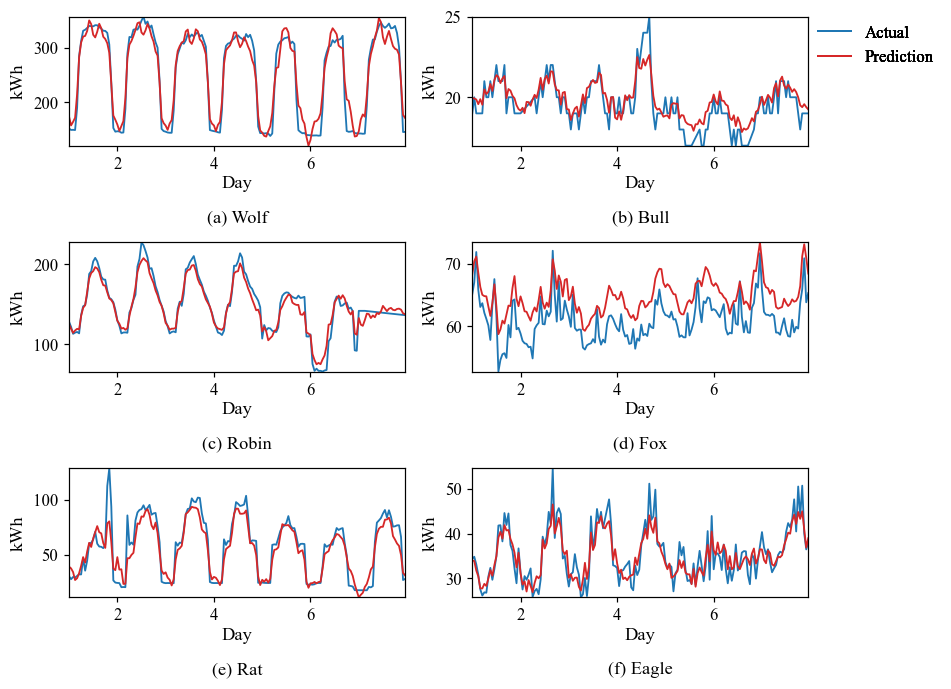

Saved -> figures\7day_forecast.png


In [13]:
def seven_day_figure(proposed="VMD_Optuna_TCN", dataset="test", days=7):
    if preds is None:
        print("Need all_predictions_long.csv"); return
    d = preds[(preds["Model"]==proposed) & (preds["Dataset"]==dataset)]
    blds = [b for b in BUILDING_ORDER if b in d["Building"].unique()]
    if not blds: print("No proposed predictions for", dataset); return
    n = days*24
    fig, axes = plt.subplots(3, 2, figsize=(8, 6))
    for ax, b in zip(axes.ravel(), blds):
        s = d[d["Building"]==b].sort_values("Timestamp").head(n)
        x = np.arange(len(s))/24 + 1
        ax.plot(x, s["Actual"].values, color="#1f77b4", lw=1.2, label="Actual")
        ax.plot(x, s["Prediction"].values, color="#d62728", lw=1.2, label="Prediction")
        ax.margins(x=0,y=0)
        ax.set_xlabel("Day", labelpad=2); ax.set_ylabel("kWh")
        ax.text(0.5, -0.5, f"({chr(97+blds.index(b))}) {b}",
                transform=ax.transAxes, ha="center", va="top")
        # if b == blds[0]:
        #     ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False, ncol=2)
        fig.legend(["Actual", "Prediction"], loc="upper right", bbox_to_anchor=(1.08, 0.98), frameon=False, ncol=1)
    for ax in axes.ravel()[len(blds):]: ax.axis("off")
    fig.subplots_adjust(hspace=0.75, wspace=0.2, left=0.08, right=0.92, top=0.97, bottom=0.09)
    p = os.path.join(FIG_DIR, "7day_forecast.png"); fig.savefig(p); plt.show()
    print("Saved ->", p)
seven_day_figure()

## 5. Predicted vs actual scatter → `figures/scatter.png`

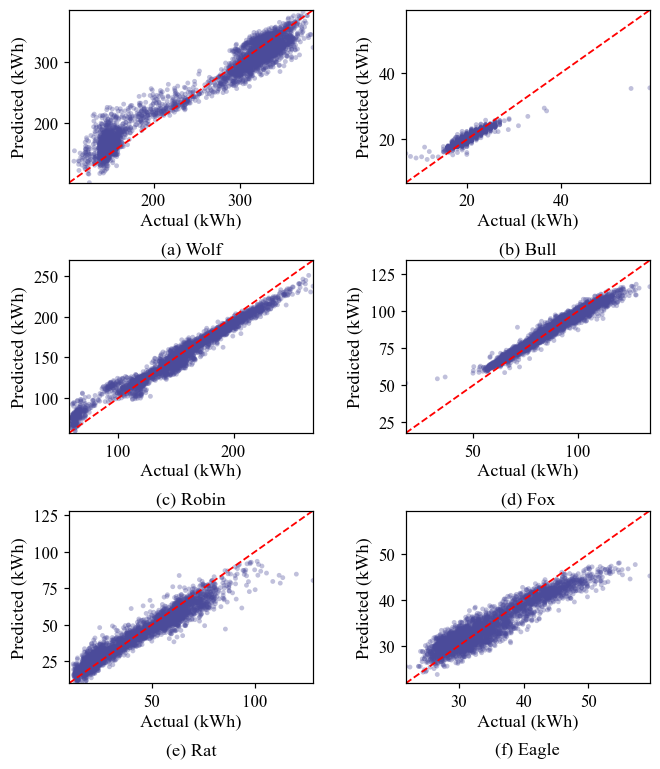

Saved -> figures\scatter.png


In [6]:
def scatter_figure(proposed="VMD_Optuna_TCN", dataset="test"):
    if preds is None: print("Need all_predictions_long.csv"); return
    d = preds[(preds["Model"]==proposed) & (preds["Dataset"]==dataset)]
    blds = [b for b in BUILDING_ORDER if b in d["Building"].unique()]
    if not blds: print("No proposed predictions"); return
    fig, axes = plt.subplots(3, 2, figsize=(6, 6.8))
    for ax, b in zip(axes.ravel(), blds):
        s = d[d["Building"]==b]
        a, p = s["Actual"].values, s["Prediction"].values
        ax.scatter(a, p, s=10, alpha=0.35, color="#4b4b9a", edgecolors="none")
        lo, hi = np.nanmin([a,p]), np.nanmax([a,p])
        ax.plot([lo,hi],[lo,hi], "r--", lw=1.2)
        ax.set_xlabel("Actual (kWh)", labelpad=2); ax.set_ylabel("Predicted (kWh)")
        ax.margins(x=0, y=0)
        ax.text(0.5, -0.34, f"({chr(97+blds.index(b))}) {b}",
                transform=ax.transAxes, ha="center", va="top")
    for ax in axes.ravel()[len(blds):]: ax.axis("off")
    fig.subplots_adjust(hspace=0.45, wspace=0.38, left=0.09, right=0.97, top=0.97, bottom=0.07)
    p = os.path.join(FIG_DIR, "scatter.png"); fig.savefig(p); plt.show()
    print("Saved ->", p)
scatter_figure()

## 6. Absolute-error box plot → `figures/absolute_error.png`

C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_19188\1917360910.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[PRETTY.get(m,m) for m in present], showfliers=False,


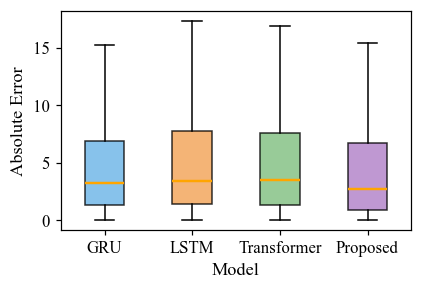

Saved -> figures\absolute_error.png


In [7]:
def abs_error_box(dataset="test"):
    long = load_csv(os.path.join(STATS_DIR, "absolute_error_long.csv"))
    if long is not None and "Abs_Error" in long.columns:
        d = long[long["Dataset"]==dataset]
        getter = lambda m: d[d["Model"]==m]["Abs_Error"].dropna().values
        present = [m for m in (MODEL_ORDER) if m in d["Model"].unique()]
    elif preds is not None:
        d = preds[preds["Dataset"]==dataset].copy()
        d["Abs_Error"] = (d["Actual"]-d["Prediction"]).abs()
        getter = lambda m: d[d["Model"]==m]["Abs_Error"].dropna().values
        present = [m for m in (MODEL_ORDER) if m in d["Model"].unique()]
    else:
        print("Need absolute_error_long.csv or all_predictions_long.csv"); return
    data = [getter(m) for m in present]
    fig, ax = plt.subplots(figsize=(4, 2.8))
    bp = ax.boxplot(data, labels=[PRETTY.get(m,m) for m in present], showfliers=False,
                    patch_artist=True)
    colors = ["#69b3e7","#f2a154","#7fbf7f","#b07fc7","#d9d36a","#e08a8a"]
    for patch, c in zip(bp["boxes"], colors): patch.set_facecolor(c); patch.set_alpha(.8)
    for med in bp["medians"]: med.set_color("orange"); med.set_linewidth(1.6)
    ax.set_xlabel("Model"); ax.set_ylabel("Absolute Error")
    ax.margins(x=0)
    fig.tight_layout()
    p = os.path.join(FIG_DIR, "absolute_error.png"); fig.savefig(p); plt.show()
    print("Saved ->", p)
abs_error_box()

## 7. Ablation table + LaTeX

Requires `run_ablation=True` in the experiment (adds `TCN` and `VMD_TCN`).
Averages each metric over the six buildings on the test set.

In [8]:
if metrics_mean is not None:
    order = ["TCN","VMD_TCN","VMD_Optuna_TCN"]
    d = metrics_mean[(metrics_mean["Dataset"]=="test") & (metrics_mean["Model"].isin(order))]
    if d["Model"].nunique() >= 2:
        tbl = (d.groupby("Model")[["MAE","RMSE","MAPE","SMAPE","R2"]].mean()
                 .reindex([m for m in order if m in d["Model"].unique()]))
        tbl.index = [PRETTY.get(m,m) for m in tbl.index]
        display(tbl.round(3))
        with open(os.path.join(FIG_DIR,"table_ablation.tex"),"w") as f:
            f.write(tbl.round(2).to_latex(escape=False))
        print("Saved -> figures/table_ablation.tex")
    else:
        print("Ablation models not found. Re-run with CONFIG['run_ablation']=True.")
else:
    print("No metrics loaded.")

,MAE,RMSE,MAPE,SMAPE,R2
TCN (raw),8.407,10.414,13.956,12.593,0.081
VMD+TCN,4.874,6.566,5.958,5.743,0.914
Proposed,5.743,7.400,6.586,6.347,0.899


Saved -> figures/table_ablation.tex


## 8. Computational-cost table + LaTeX

In [9]:
if complexity is not None:
    c = complexity.groupby("Model", as_index=False).agg(
        Trainable_Params=("Trainable_Params","mean"),
        Training_Time_sec=("Training_Time_sec","mean"))
    order = [m for m in ["GRU","LSTM","Transformer","TCN","VMD_TCN","VMD_Optuna_TCN"]
             if m in c["Model"].unique()]
    c = c.set_index("Model").reindex(order)
    # add mean test inference time from metrics if available
    if metrics_mean is not None:
        inf = (metrics_mean[metrics_mean["Dataset"]=="test"]
               .groupby("Model")["Testing_Time_sec"].mean())
        c["Inference_Time_sec"] = inf
    c.index = [PRETTY.get(m,m) for m in c.index]
    display(c.round({"Trainable_Params":0,"Training_Time_sec":2,"Inference_Time_sec":3}))
    with open(os.path.join(FIG_DIR,"table_cost.tex"),"w") as f:
        f.write(c.round(2).to_latex(escape=False))
    print("Saved -> figures/table_cost.tex")
else:
    print("No model_complexity.csv (set CONFIG['record_complexity']=True and re-run).")

,Trainable_Params,Training_Time_sec,Inference_Time_sec
GRU,152472.0,62.70,0.033
LSTM,202264.0,93.40,0.047
Transformer,253720.0,120.34,0.056
TCN (raw),133816.0,701.20,0.957
VMD+TCN,133816.0,4201.35,5.701
Proposed,133816.0,4200.32,5.633


Saved -> figures/table_cost.tex


## 9. Statistical tests (block-level Wilcoxon, Friedman) + LaTeX

In [10]:
block = load_csv(os.path.join(STATS_DIR, "block_level_wilcoxon_tests.csv"))
if block is not None:
    keep = [c for c in ["Metric","Baseline_Model","Statistic","P_Value",
                        "Median_Diff_BaselineMinusProposed","Significant_at_alpha"] if c in block.columns]
    display(block[keep])
    with open(os.path.join(FIG_DIR,"table_wilcoxon.tex"),"w") as f:
        f.write(block[keep].to_latex(index=False, escape=False))
    print("Saved -> figures/table_wilcoxon.tex")

friedman = load_csv(os.path.join(STATS_DIR, "friedman_tests.csv"))
if friedman is not None:
    display(friedman)

,Metric,Baseline_Model,Statistic,P_Value,Median_Diff_BaselineMinusProposed,Significant_at_alpha
0,MAE,GRU,62.0,0.136719,0.558941,False
1,MAE,LSTM,78.0,0.010742,1.034239,True
2,MAE,Transformer,66.0,0.083862,0.811266,False
3,RMSE,GRU,68.0,0.063599,0.874882,False
4,RMSE,LSTM,82.0,0.004028,1.522713,True
5,RMSE,Transformer,70.0,0.047119,1.071407,True
6,MAPE,GRU,71.0,0.040161,1.367155,True
7,MAPE,LSTM,83.0,0.003052,1.333689,True
8,MAPE,Transformer,80.0,0.006714,1.876906,True
9,SMAPE,GRU,71.0,0.040161,1.336921,True


Saved -> figures/table_wilcoxon.tex


,Metric,Friedman_Statistic,P_Value,N_Blocks,N_Models,Significant_at_alpha,Note
0,MAE,13.800000,0.003190,13,4,True,Lower rank is better for this metric.
1,RMSE,16.292308,0.000988,13,4,True,Lower rank is better for this metric.
2,MAPE,11.492308,0.009341,13,4,True,Lower rank is better for this metric.
3,SMAPE,12.784615,0.005126,13,4,True,Lower rank is better for this metric.


## 10. Generalization: held-out month & unseen building + LaTeX

`holdout` = December-2017 window of the six training buildings.
`cross`   = the unseen building **Hog** (never used in training).
This is the experiment your manuscript's introduction promised — report it.

In [11]:
if metrics_mean is not None:
    gen = metrics_mean[metrics_mean["Dataset"].isin(["holdout","cross"])]
    if len(gen):
        piv = gen.pivot_table(index=["Dataset","Building"], columns="Model",
                              values="MAPE")
        cols = [m for m in MODEL_ORDER if m in piv.columns]
        piv = piv[cols].rename(columns=PRETTY)
        display(piv.round(2))
        with open(os.path.join(FIG_DIR,"table_generalization.tex"),"w") as f:
            f.write(piv.round(2).to_latex(escape=False))
        print("Saved -> figures/table_generalization.tex (MAPE shown; change 'values' for others)")
    else:
        print("No holdout/cross rows. Ensure test_buildings includes 'Hog' and a holdout period.")

Model               GRU   LSTM  Transformer  Proposed
Dataset Building                                     
cross   Hog        2.54   2.82         4.21      2.33
holdout Bull       7.86   6.42         7.04      4.19
        Eagle      4.47   3.76         5.60      2.74
        Fox        4.89   5.16         6.32      4.27
        Rat       13.29  13.28        10.84     10.61
        Robin      5.02   6.90         7.08      5.37
        Wolf       6.01   8.72         6.09      7.87

Saved -> figures/table_generalization.tex (MAPE shown; change 'values' for others)


## 11. *(optional)* Building distribution & VMD IMF overlay

These regenerate `building_distribution.png` and `IMFs_Overlay.png` in Times New Roman
directly from the raw data. They need the raw CSV (from `download_data.py`) and, for the
IMF overlay, `vmdpy` (`pip install vmdpy`). Skipped automatically if unavailable.

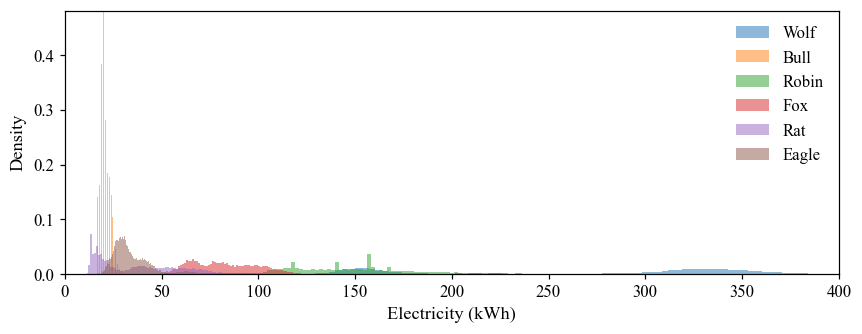

Saved -> figures\building_distribution.png


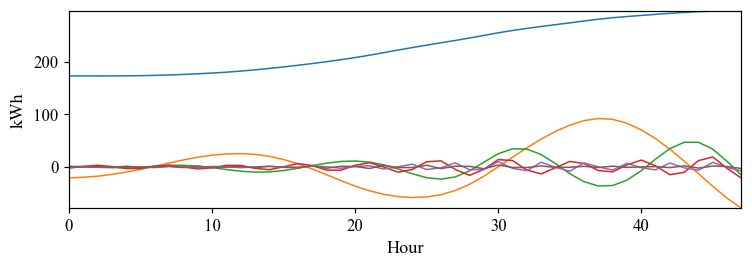

Saved -> figures\IMFs_Overlay.png


In [12]:
RAW_CSV = os.path.join("meters","cleaned","electricity_cleaned.csv")
def find_col(df, b): 
    m=[c for c in df.columns if b.lower() in c.lower()]; return m[0] if m else None

if os.path.exists(RAW_CSV):
    raw = pd.read_csv(RAW_CSV, parse_dates=["timestamp"])
    # ---- distribution ----
    fig, ax = plt.subplots(figsize=(8,3.2))
    for b in BUILDING_ORDER:
        col = find_col(raw, b)
        if col: ax.hist(pd.to_numeric(raw[col],errors="coerce").dropna(),
                        bins=120, density=True, alpha=0.5, label=b)
    ax.set_xlabel("Electricity (kWh)"); ax.set_ylabel("Density")
    ax.margins(x=0,y=0)
    ax.legend(loc="upper right", frameon=False, ncol=1)
    ax.set_xlim(0, 400)
    fig.tight_layout(); p=os.path.join(FIG_DIR,"building_distribution.png")
    fig.savefig(p); plt.show(); print("Saved ->",p)

    # ---- IMF overlay (Wolf, 48h) ----
    try:
        from vmdpy import VMD
        col = find_col(raw, "Wolf")
        sig = pd.to_numeric(raw[col],errors="coerce").interpolate().bfill().ffill().values
        u,_,_ = VMD(sig, 2000, 0, 6, 0, 1, 1e-7)
        fig, ax = plt.subplots(figsize=(7,2.6))
        for i in range(u.shape[0]): ax.plot(u[i][:48], lw=1.0)
        ax.set_xlabel("Hour"); ax.set_ylabel("kWh"); fig.tight_layout()
        ax.margins(x=0,y=0)
        p=os.path.join(FIG_DIR,"IMFs_Overlay.png"); fig.savefig(p); plt.show()
        print("Saved ->",p)
    except Exception as e:
        print("IMF overlay skipped:", e)
else:
    print("Raw CSV not found at", RAW_CSV, "- run download_data.py first (optional).")